# Vehicle Policy Lapse Prediction

## Exploratory Data Analysis (EDA)

### Objective
Analyze the vehicle insurance dataset to identify patterns and factors associated with policy lapse behavior.

### Business Context
Policy lapse directly impacts customer retention and recurring premium revenue, making lapse prediction an important business problem for insurers.

This analysis focuses on understanding customer, policy, vehicle, and premium related characteristics that may contribute to lapse risk.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
import warnings

# Suppress non critical warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=FutureWarning)

# Ignore numerical runtime warnings during calculations
np.seterr(divide="ignore", invalid="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

### Load Dataset

Load the vehicle insurance policy dataset and validate the dataset path before beginning exploratory analysis.

In [3]:
base_dir = Path().resolve().parent

data_path = base_dir / "data" / "eudirectlapse.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

df = pd.read_csv(data_path)

df.head()

,lapse,polholder_age,polholder_BMCevol,polholder_diffdriver,polholder_gender,polholder_job,policy_age,policy_caruse,policy_nbcontract,prem_final,prem_freqperyear,prem_last,prem_market,prem_pure,vehicl_age,vehicl_agepurchase,vehicl_garage,vehicl_powerkw,vehicl_region
0,0,38,stable,only partner,Male,normal,1,private or freelance work,1,232.46,4 per year,232.47,221.56,243.59,9,8,private garage,225 kW,Reg7
1,1,35,stable,same,Male,normal,1,private or freelance work,1,208.53,4 per year,208.54,247.56,208.54,15,7,private garage,100 kW,Reg4
2,1,29,stable,same,Male,normal,0,private or freelance work,1,277.34,1 per year,277.35,293.32,277.35,14,6,underground garage,100 kW,Reg7
3,0,33,down,same,Female,medical,2,private or freelance work,1,239.51,4 per year,244.40,310.91,219.95,17,10,street,75 kW,Reg5
4,0,50,stable,same,Male,normal,8,unknown,1,554.54,4 per year,554.55,365.46,519.50,16,8,street,75 kW,Reg14


## Dataset Overview

Inspect the dataset structure and basic characteristics before performing detailed analysis.

In [4]:
print("Shape:", df.shape)

Shape: (23060, 19)


In [5]:
print(df.dtypes.value_counts())

object     9
int64      6
float64    4
Name: count, dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23060 entries, 0 to 23059
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lapse                 23060 non-null  int64  
 1   polholder_age         23060 non-null  int64  
 2   polholder_BMCevol     23060 non-null  object 
 3   polholder_diffdriver  23060 non-null  object 
 4   polholder_gender      23060 non-null  object 
 5   polholder_job         23060 non-null  object 
 6   policy_age            23060 non-null  int64  
 7   policy_caruse         23060 non-null  object 
 8   policy_nbcontract     23060 non-null  int64  
 9   prem_final            23060 non-null  float64
 10  prem_freqperyear      23060 non-null  object 
 11  prem_last             23060 non-null  float64
 12  prem_market           23060 non-null  float64
 13  prem_pure             23060 non-null  float64
 14  vehicl_age            23060 non-null  int64  
 15  vehicl_agepurchase 

#### Initial Observations

- The dataset contains 23,060 insurance policies with 19 features and no missing values.
- Features include a mix of customer, policy, premium, and vehicle related information.
- The dataset contains both numerical and categorical variables, indicating that preprocessing and encoding will be required before modeling.
- Several premium related variables are present (`prem_final`, `prem_last`, `prem_market`, `prem_pure`), which may introduce multicollinearity and will require further analysis.
- No immediate data quality concerns are observed at the structural level.

### Numerical Feature Summary

In [7]:
df.describe()

,lapse,polholder_age,policy_age,policy_nbcontract,prem_final,prem_last,prem_market,prem_pure,vehicl_age,vehicl_agepurchase
count,23060.000000,23060.000000,23060.000000,23060.000000,23060.000000,23060.000000,23060.000000,23060.000000,23060.000000,23060.000000
mean,0.128101,43.045490,2.443452,1.305637,374.123791,380.508774,373.528631,355.882315,13.060624,7.680876
std,0.334209,12.352291,3.100771,0.788647,212.899174,227.937859,201.915809,197.138010,3.590088,4.960701
min,0.000000,19.000000,0.000000,1.000000,46.550000,46.560000,50.110000,45.550000,0.000000,0.000000
25%,0.000000,35.000000,0.000000,1.000000,232.837500,232.630000,245.150000,227.100000,11.000000,4.000000
50%,0.000000,41.000000,1.000000,1.000000,312.250000,311.005000,316.830000,301.445000,13.000000,8.000000
75%,0.000000,49.000000,4.000000,1.000000,448.370000,449.602500,434.452500,423.562500,16.000000,11.000000
max,1.000000,85.000000,17.000000,15.000000,2948.050000,3362.070000,2416.840000,2716.080000,18.000000,18.000000


#### Observations

- The dataset is imbalanced, with around 13% policy lapses.
- Most policyholders are between 35 and 50 years old.
- Many policies are fairly new, as the median policy age is 1 year.
- Premium related features have very similar distributions, which may indicate strong correlation between them.
- Some premium values are much higher than the average and may need further investigation.
- Vehicle age and vehicle purchase age both show good variation across the dataset.

### Categorical Feature Summary

In [8]:
categorical_cols = df.select_dtypes(include="object").columns

df[categorical_cols].describe()

,polholder_BMCevol,polholder_diffdriver,polholder_gender,polholder_job,policy_caruse,prem_freqperyear,vehicl_garage,vehicl_powerkw,vehicl_region
count,23060,23060,23060,23060,23060,23060,23060,23060,23060
unique,3,7,2,2,3,4,8,11,14
top,stable,same,Male,normal,private or freelance work,1 per year,private garage,75 kW,Reg4
freq,12036,11155,14721,13578,19567,11680,8863,10339,4325


#### Observations

- The dataset contains a mix of customer, policy, and vehicle related categorical features.
- Some features have only a few categories, while others such as `vehicl_region` and `vehicl_powerkw` contain more variation.
- Most policyholders are male, and most belong to the `normal` job category.
- Private or freelance vehicle use is the most common usage type in the dataset.
- Annual premium payment is the most common payment frequency.
- A few categories dominate certain features, which may influence their predictive value during modeling.

In [9]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

missing_values = df.isnull().sum().sum()
print(f"Missing values: {missing_values}")

Duplicate rows: 0
Missing values: 0


## Target Variable Distribution

In [10]:
lapse_distribution = pd.DataFrame({
    "count": df["lapse"].value_counts(),
    "proportion": df["lapse"].value_counts(normalize=True).round(3)            
})

lapse_distribution

,count,proportion
lapse,,
0,20106,0.872
1,2954,0.128


### Observations

- Majority class: 87.2% non-lapse (20,106 policies)
- Minority class: 12.8% lapse (2,954 policies)
- The dataset shows a moderate class imbalance
- Recall will be an important metric for identifying lapse cases during modeling

## Feature Analysis

### Customer Features

- `polholder_age`
- `polholder_gender`
- `polholder_job`
- `polholder_diffdriver`
- `polholder_BMCevol`

These features describe customer demographics and driver related characteristics that may influence policy renewal and lapse behavior.

#### Policyholder Age

Represents the age of the policyholder. It is an important behavioral and financial indicator in insurance and can influence:

- driving experience
- claim risk
- income stability
- renewal behavior
- price sensitivity

In policy lapse prediction, age helps identify customer segments that may be more likely to discontinue coverage.

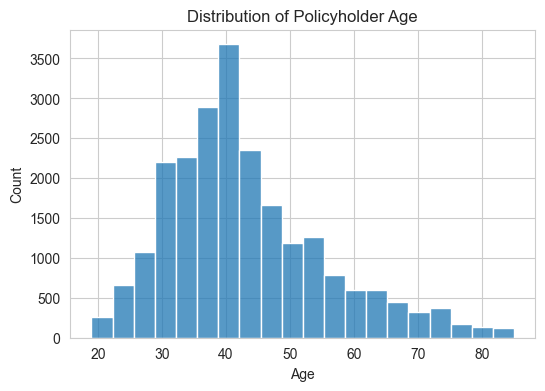

In [11]:
plt.figure(figsize=(6, 4))

sns.histplot(df["polholder_age"], bins=20)

plt.title("Distribution of Policyholder Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

##### Observations

- Most policyholders are between 30 and 50 years old.
- The age distribution is slightly right-skewed, with fewer older policyholders.
- Very young and very old customers represent a smaller portion of the dataset.
- No major outliers or unrealistic age values are observed.
- Policyholder age appears to provide useful variation for lapse prediction.

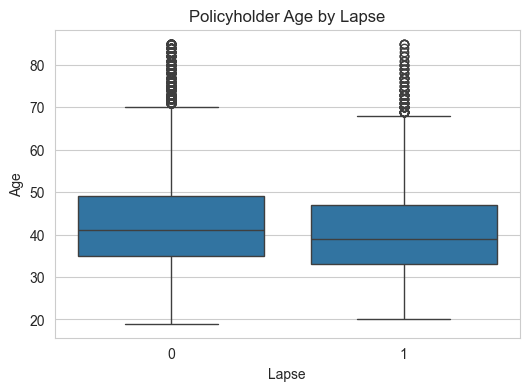

In [12]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="lapse",
    y="polholder_age"
)

plt.title("Policyholder Age by Lapse")
plt.xlabel("Lapse")
plt.ylabel("Age")

plt.show()

##### Observations

- Non-lapsed customers have a slightly higher average age compared to lapsed customers.
- The median age is lower for customers who lapsed, indicating that younger policyholders may be more likely to discontinue coverage.
- Both groups show a similar age range and variability.
- The difference is moderate, but age may still provide useful predictive signal for lapse behavior.

In [13]:
age_bins = [18, 30, 40, 50, 60, 70, 90]
age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

df["age_group"] = pd.cut(
    df["polholder_age"], bins=age_bins, labels=age_labels
)

age_labels_rate = (
    df.groupby("age_group")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)
age_labels_rate

,age_group,lapse
0,18-29,0.173
1,30-39,0.134
2,40-49,0.122
3,50-59,0.112
4,60-69,0.101
5,70+,0.070


##### Observations

- The highest lapse rate is observed among policyholders aged 18–29.
- Lapse rates consistently decrease as age increases.
- Older customers appear more stable and less likely to discontinue coverage.
- Policyholders aged 70+ show the lowest lapse rate.
- Age appears to be an important feature for predicting policy lapse behavior.

#### Policyholder Gender

Represents the gender of the policyholder.

Gender may influence insurance behavior through differences in driving patterns, vehicle usage, risk exposure, and renewal tendencies. Analyzing this feature helps identify whether lapse behavior varies across customer groups.

In [14]:
gender_lapse_rate = (
    df.groupby("polholder_gender")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)
gender_lapse_rate

,polholder_gender,lapse
0,Female,0.120
1,Male,0.133


##### Observations

- Male policyholders show a slightly higher lapse rate compared to female policyholders.
- The difference in lapse behavior between genders is relatively small.
- Gender may provide limited predictive signal compared to stronger behavioral or pricing related features.



#### Policyholder Job

Represents the occupation category of the policyholder.

Occupation may reflect differences in income stability, lifestyle, vehicle usage, and financial behavior. These factors can influence insurance renewal patterns and policy lapse behavior across customer segments.

In [15]:
job_lapse_rate = (
    df.groupby("polholder_job")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)
job_lapse_rate

,polholder_job,lapse
0,medical,0.121
1,normal,0.133


##### Observations

- Policyholders in the normal job category show a slightly higher lapse rate compared to those in the medical category.
- The difference between groups is relatively small.
- Occupation may provide some predictive signal, but its influence appears limited compared to stronger demographic or policy related features.

#### Different Driver Status

Indicates whether the primary driver of the vehicle is different from the policyholder.

This feature may reflect shared vehicle usage, family owned vehicles, or more complex driving arrangements, which can influence policy usage patterns and renewal behavior.

In [16]:
diffdriver_lapse_rate = (
    df.groupby("polholder_diffdriver")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

diffdriver_lapse_rate

,polholder_diffdriver,lapse
0,all drivers > 24,0.119
1,commercial,0.050
2,learner 17,0.190
3,only partner,0.128
4,same,0.123
5,unknown,0.167
6,young drivers,0.167


##### Observations

- Policies involving learner or young drivers show noticeably higher lapse rates.
- Commercial driver policies have the lowest lapse rate among all groups.
- Policies where the driver and policyholder are the same show relatively lower lapse behavior.
- The variation across driver categories suggests that driver status may provide meaningful predictive signal for lapse prediction.

#### Bonus Malus Evolution

Represents the change or evolution of the policyholder’s Bonus Malus score over time.

The Bonus Malus system reflects a customer’s claim and risk history. Changes in this score may influence premium adjustments, customer satisfaction, and renewal behavior, making it potentially important for policy lapse prediction.

In [17]:
bmcevol_lapse_rate = (
    df.groupby("polholder_BMCevol")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

bmcevol_lapse_rate

,polholder_BMCevol,lapse
0,down,0.161
1,stable,0.102
2,up,0.098


##### Observations

- Policyholders with a decreasing Bonus Malus score show the highest lapse rate.
- Stable and improving Bonus-Malus categories have noticeably lower lapse rates.
- Customers experiencing negative Bonus Malus changes may be more likely to discontinue coverage.
- The feature shows clear variation across groups and appears to provide strong predictive signal for lapse behavior.

### Policy Features

- `policy_age`
- `policy_caruse`
- `policy_nbcontract`

These features describe policy duration, contract characteristics, and vehicle usage patterns that may influence customer renewal and lapse behavior.

#### Policy Age

Represents the duration of the insurance policy.

Policy age may reflect customer loyalty, relationship stability, and renewal history. Newer policies may be more likely to lapse, while long term customers are often more stable and retained over time.

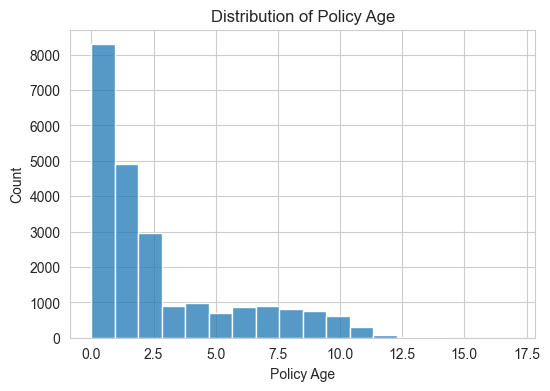

In [18]:
plt.figure(figsize=(6, 4))

sns.histplot(df["policy_age"], bins=18)

plt.title("Distribution of Policy Age")
plt.xlabel("Policy Age")
plt.ylabel("Count")

plt.show()

##### Observations

- The distribution of policy age is heavily right-skewed.
- Most customers have relatively new policies, with a large concentration at lower policy ages.
- The number of policies decreases as policy age increases.
- Very old policies are relatively uncommon in the dataset.
- Policy age may provide useful signal for understanding customer retention and lapse behavior.

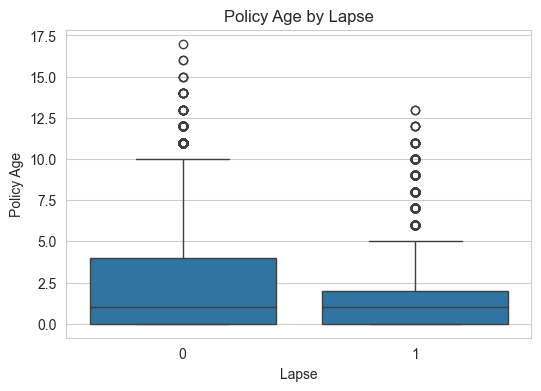

In [19]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="lapse",
    y="policy_age"
)

plt.title("Policy Age by Lapse")
plt.xlabel("Lapse")
plt.ylabel("Policy Age")

plt.show()

##### Observations

- Non-lapsed customers have a higher average policy age compared to lapsed customers.
- Customers with newer policies appear more likely to lapse.
- The median policy age is similar across both groups, though non-lapsed policies show a wider spread and higher maximum values.
- Longer policy duration may indicate stronger customer retention and policy stability.
- Policy age appears to provide meaningful predictive signal for lapse prediction.

In [20]:
policy_lapse_rate = (
    df.groupby("policy_age")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

policy_lapse_rate

,policy_age,lapse
0,0,0.134
1,1,0.154
2,2,0.136
3,3,0.133
4,4,0.144
5,5,0.109
6,6,0.067
7,7,0.079
8,8,0.095
9,9,0.092


##### Observations

- Policies with lower policy age generally show higher lapse rates.
- Lapse rates tend to decrease as policy age increases, suggesting stronger retention among long term customers.
- Customers with policies older than five years appear relatively more stable.
- Very high policy ages contain few observations, making those lapse rates less reliable.
- The overall trend indicates that policy age is an important feature for predicting lapse behavior.


#### Policy Car Use

Represents the primary usage type of the insured vehicle.

Vehicle usage patterns may influence driving exposure, claim risk, and customer behavior. Different usage categories can reflect varying insurance needs and renewal tendencies, which may affect policy lapse behavior.

In [21]:
caruse_lapse_rate = (
    df.groupby("policy_caruse")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

caruse_lapse_rate

,policy_caruse,lapse
0,commercial,0.200
1,private or freelance work,0.136
2,unknown,0.084


##### Observations

- Commercial vehicle policies show the highest lapse rate among all usage categories.
- Policies used for private or freelance work show moderate lapse behavior.
- Policies with unknown usage type have the lowest observed lapse rate.
- The variation across usage categories suggests that vehicle usage patterns may influence customer renewal behavior.
- `policy_caruse` appears to provide useful predictive signal for lapse prediction.


#### Number of Contracts

Represents the number of insurance contracts associated with the policyholder.

Customers with multiple contracts may have stronger relationships with the insurer and higher customer loyalty. The number of contracts may therefore influence renewal behavior and policy lapse risk.

In [22]:
contract_lapse_rate = (
    df.groupby("policy_nbcontract")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

contract_lapse_rate

,policy_nbcontract,lapse
0,1,0.129
1,2,0.124
2,3,0.136
3,4,0.111
4,5,0.092
5,6,0.179
6,7,0.161
7,8,0.111
8,9,0.167
9,10,0.091


##### Observations

- Customers with fewer contracts show moderate lapse rates overall.
- Policies associated with five contracts show relatively lower lapse behavior, suggesting stronger customer retention.
- Some higher contract counts display higher lapse rates, though these groups may contain fewer observations.
- Very high contract counts have limited or no observations, making those lapse rates less reliable.
- The relationship between number of contracts and lapse behavior appears mixed but may still provide useful predictive signal.

### Premium Features

- `prem_final`
- `prem_last`
- `prem_market`
- `prem_pure`
- `prem_freqperyear`

These features describe premium pricing and payment-related characteristics that may influence customer affordability, renewal decisions, and policy lapse behavior.

#### Final Premium

Represents the final premium amount paid for the insurance policy.

Premium amount is a key factor influencing customer affordability and renewal decisions. Higher premiums may increase the likelihood of policy lapse, while more affordable pricing may support stronger customer retention.

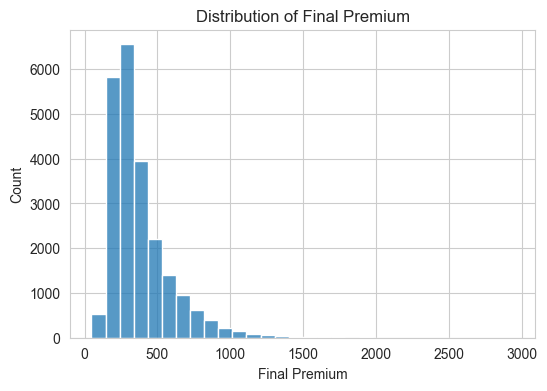

In [23]:
plt.figure(figsize=(6, 4))

sns.histplot(df["prem_final"], bins=30)

plt.title("Distribution of Final Premium")
plt.xlabel("Final Premium")
plt.ylabel("Count")

plt.show()

##### Observations

- The distribution of final premium is strongly right-skewed.
- Most policies fall within the lower premium range, while a smaller number of policies have very high premium values.
- A few extreme premium values are observed, potentially representing high-risk or high-value policies.
- Premium-related features may require careful handling during modeling due to their skewed distribution.
- Final premium appears to be an important feature for lapse prediction, as pricing can strongly influence customer renewal decisions.

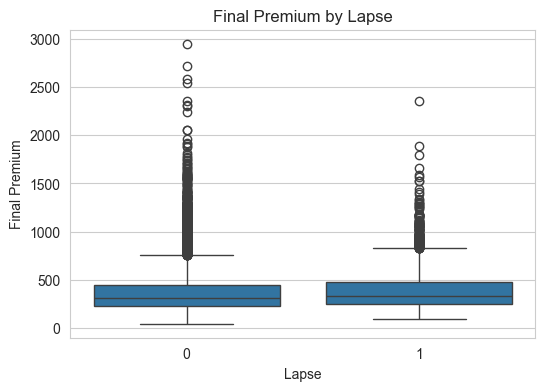

In [24]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="lapse",
    y="prem_final"
)

plt.title("Final Premium by Lapse")
plt.xlabel("Lapse")
plt.ylabel("Final Premium")

plt.show()

##### Observations

- Customers who lapsed have a higher average and median final premium compared to non-lapsed customers.
- Higher premium amounts may increase the likelihood of customer discontinuation due to affordability or price sensitivity.
- Both groups show wide variation in premium values, with some extremely high premiums present in the dataset.
- The feature exhibits substantial spread and right skewness, which may require careful handling during modeling.
- Final premium appears to provide meaningful predictive signal for lapse behavior.

In [25]:
premium_bins = [0, 200, 400, 600, 800, 1000, 3000]
premium_labels = ["0-200", "200-400", "400-600", "600-800", "800-1000", "1000+"]

df["premium_group"] = pd.cut(
    df["prem_final"],
    bins=premium_bins,
    labels=premium_labels
)

premium_lapse_rate = (
    df.groupby("premium_group")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

premium_lapse_rate

,premium_group,lapse
0,0-200,0.106
1,200-400,0.122
2,400-600,0.150
3,600-800,0.143
4,800-1000,0.156
5,1000+,0.159


##### Observations

- Lapse rates generally increase as premium amount increases.
- Customers in lower premium ranges show relatively lower lapse behavior.
- Higher premium groups exhibit noticeably higher lapse rates, suggesting increased price sensitivity.
- The trend indicates that premium affordability may strongly influence customer renewal decisions.
- Final premium appears to be an important feature for predicting lapse behavior.

In [26]:
premium_cols = [
    "prem_final",
    "prem_last",
    "prem_market",
    "prem_pure"
]

df[premium_cols].corr()

,prem_final,prem_last,prem_market,prem_pure
prem_final,1.000000,0.950642,0.894923,0.990542
prem_last,0.950642,1.000000,0.838543,0.925565
prem_market,0.894923,0.838543,1.000000,0.899280
prem_pure,0.990542,0.925565,0.899280,1.000000


##### Observations

- Premium-related features show very strong positive correlations with each other.
- `prem_final` and `prem_pure` are almost perfectly correlated.
- The high correlation between premium variables suggests potential multicollinearity.
- These features may contain overlapping information and should be reviewed carefully during feature selection.
- Linear models may be more sensitive to this redundancy, while tree-based models can typically handle correlated features more effectively.

#### Premium Payment Frequency

Represents how frequently the insurance premium is paid within a year.

Payment frequency may reflect customer affordability preferences and financial behavior. Customers choosing more frequent payment schedules may exhibit different renewal and lapse tendencies compared to those paying annually or less frequently.

In [27]:
payment_lapse_rate = (
    df.groupby("prem_freqperyear")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

payment_lapse_rate

,prem_freqperyear,lapse
0,1 per year,0.140
1,12 per year,0.114
2,2 per year,0.129
3,4 per year,0.110


##### Observations

- Customers paying premiums once per year show the highest lapse rate among all payment frequencies.
- More frequent payment schedules, such as monthly or quarterly payments, are associated with lower lapse rates.
- Flexible payment options may help improve customer retention by reducing immediate financial burden.
- The variation across payment frequencies suggests that payment behavior may provide useful predictive signal for lapse prediction.


### Vehicle Features

- `vehicl_age`
- `vehicl_agepurchase`
- `vehicl_garage`
- `vehicl_powerkw`
- `vehicl_region`

These features describe vehicle characteristics, ownership patterns, and location-related information that may influence insurance risk, pricing, and policy lapse behavior.

#### Vehicle Age

Represents the age of the insured vehicle.

Vehicle age may influence insurance pricing, maintenance costs, vehicle value, and customer usage patterns. Different vehicle age groups may exhibit varying renewal tendencies and lapse behavior.

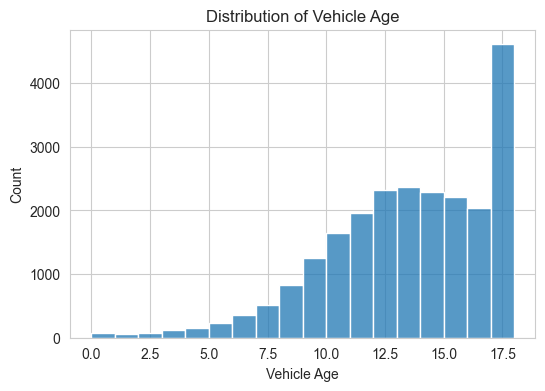

In [28]:
plt.figure(figsize=(6, 4))

sns.histplot(df["vehicl_age"], bins=18)

plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Count")

plt.show()

##### Observations

- The distribution of vehicle age is left-skewed, with a large concentration of older vehicles.
- Most vehicles in the dataset are between 10 and 18 years old.
- Newer vehicles represent a smaller portion of the dataset.
- The dataset appears to contain a relatively mature vehicle portfolio.
- Vehicle age may influence both insurance pricing and customer renewal behavior.

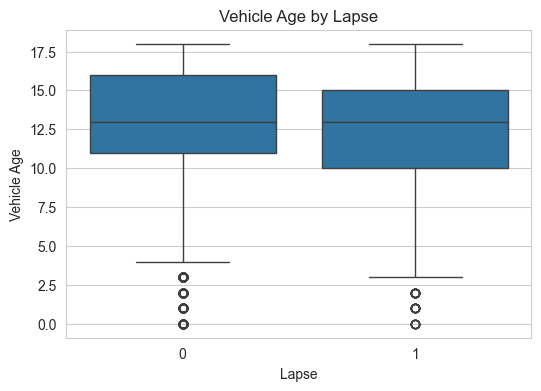

In [29]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="lapse",
    y="vehicl_age"
)

plt.title("Vehicle Age by Lapse")
plt.xlabel("Lapse")
plt.ylabel("Vehicle Age")

plt.show()

##### Observations

- Non-lapsed customers have a slightly higher average vehicle age compared to lapsed customers.
- The median vehicle age is similar across both groups.
- The difference between groups is relatively small, suggesting that vehicle age alone may provide limited predictive signal.
- Both groups show similar variability and vehicle age ranges.
- Vehicle age may still contribute useful information when combined with other policy and pricing-related features.

In [30]:
vehicle_age_lapse_rate = (
    df.groupby("vehicl_age")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

vehicle_age_lapse_rate

,vehicl_age,lapse
0,0,0.088
1,1,0.150
2,2,0.169
3,3,0.193
4,4,0.183
5,5,0.155
6,6,0.146
7,7,0.168
8,8,0.155
9,9,0.139


##### Observations

- Very new vehicles show relatively lower lapse rates.
- Mid-aged vehicles generally exhibit higher lapse behavior compared to newer and older vehicles.
- Lapse rates gradually decline for older vehicle age groups.
- The relationship between vehicle age and lapse behavior appears non-linear.
- Vehicle age may provide useful predictive signal when combined with other customer and pricing-related features.

#### Vehicle Purchase Age

Represents the age of the vehicle at the time of purchase.

This feature may reflect customer purchasing behavior, vehicle value, and ownership patterns. Vehicles purchased at different ages may be associated with varying insurance costs, usage behavior, and renewal tendencies, which can influence policy lapse behavior.

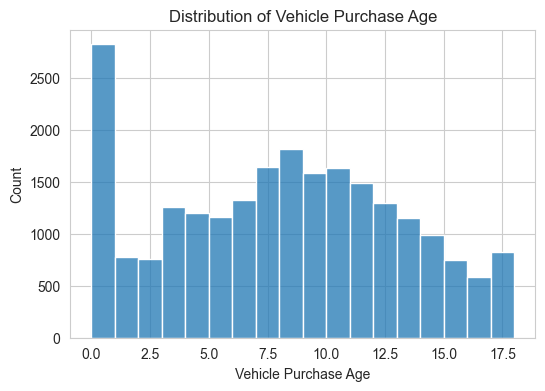

In [31]:
plt.figure(figsize=(6, 4))

sns.histplot(df["vehicl_agepurchase"], bins=18)

plt.title("Distribution of Vehicle Purchase Age")
plt.xlabel("Vehicle Purchase Age")
plt.ylabel("Count")

plt.show()

##### Observations

- Vehicle purchase age is distributed across a wide range of values.
- A noticeable number of vehicles were purchased very recently (`0` years).
- Mid-range purchase ages appear more common than very old purchase ages.
- The feature shows reasonable variation and may help capture vehicle ownership behavior.

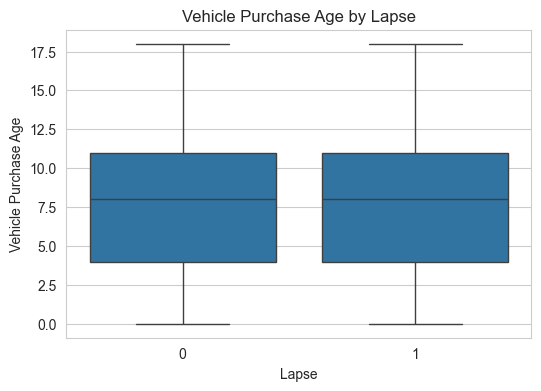

In [32]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="lapse",
    y="vehicl_agepurchase"
)

plt.title("Vehicle Purchase Age by Lapse")
plt.xlabel("Lapse")
plt.ylabel("Vehicle Purchase Age")

plt.show()

##### Observations

- The average and median vehicle purchase age are very similar across lapsed and non-lapsed customers.
- Both groups show comparable variability and age ranges.
- The feature does not display strong separation between lapse categories based on summary statistics alone.
- Vehicle purchase age may provide limited standalone predictive signal, though it could still contribute useful contextual information when combined with other features.

In [33]:
purchase_age_lapse_rate = (
    df.groupby("vehicl_agepurchase")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

purchase_age_lapse_rate

,vehicl_agepurchase,lapse
0,0,0.108
1,1,0.120
2,2,0.123
3,3,0.144
4,4,0.130
5,5,0.137
6,6,0.145
7,7,0.164
8,8,0.143
9,9,0.149


##### Observations

- Vehicles purchased very recently tend to show relatively lower lapse rates.
- Lapse rates generally increase for mid-range vehicle purchase ages before declining again for older purchase ages.
- The relationship between vehicle purchase age and lapse behavior appears non-linear.
- Customers with vehicles purchased around 6–10 years ago show comparatively higher lapse behavior.
- Vehicle purchase age may provide moderate predictive signal when combined with other vehicle and pricing-related features.

#### Vehicle Garage Type

Represents the type of garage or parking arrangement associated with the insured vehicle.

Garage type may reflect differences in vehicle security, ownership conditions, and customer profile characteristics. These factors can influence insurance risk, pricing, and customer renewal behavior.

In [34]:
garage_lapse_rate = (
    df.groupby("vehicl_garage")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

garage_lapse_rate

,vehicl_garage,lapse
0,carport,0.137
1,other,0.128
2,parking deck,0.127
3,private estate,0.080
4,private garage,0.125
5,street,0.124
6,underground garage,0.166
7,unknown,0.138


##### Observations

- Vehicles parked in underground garages show the highest lapse rate among garage categories.
- Policies associated with private estates show relatively lower lapse behavior.
- Most garage categories exhibit fairly similar lapse rates overall.
- The variation across garage types is moderate, suggesting that garage arrangement may provide some contextual predictive signal.
- The feature may contribute additional information when combined with other vehicle and policy-related variables.


#### Vehicle Power

Represents the engine power of the insured vehicle, typically measured in kilowatts (kW).

Vehicle power may influence driving behavior, insurance risk, premium pricing, and customer affordability. Higher-powered vehicles may be associated with different usage patterns and renewal tendencies, which can affect policy lapse behavior.

In [35]:
power_lapse_rate = (
    df.groupby("vehicl_powerkw")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

power_lapse_rate

,vehicl_powerkw,lapse
0,100 kW,0.133
1,125-300 kW,0.119
2,150 kW,0.121
3,175 kW,0.121
4,200 kW,0.062
5,225 kW,0.104
6,25-50 kW,0.123
7,250 kW,0.125
8,275 kW,0.000
9,300 kW,0.000


##### Observations

- Most vehicle power categories show relatively similar lapse rates overall.
- Certain high-power categories display lower or zero lapse rates, though these groups may contain very few observations.
- Vehicles with 200 kW show noticeably lower lapse behavior compared to other categories.
- Extremely high-power categories likely contain sparse observations, making those lapse rates less reliable.
- Vehicle power appears to provide limited to moderate predictive signal for lapse behavior.


#### Vehicle Region

Represents the geographical region associated with the insured vehicle or policyholder.

Regional differences may reflect variations in traffic conditions, urbanization, driving behavior, claim risk, and customer demographics. These factors can influence insurance pricing, renewal behavior, and policy lapse risk.

In [36]:
region_lapse_rate = (
    df.groupby("vehicl_region")["lapse"]
    .mean()
    .round(3)
    .reset_index()
)

region_lapse_rate

,vehicl_region,lapse
0,Reg1,0.105
1,Reg10,0.132
2,Reg11,0.154
3,Reg12,0.180
4,Reg13,0.144
5,Reg14,0.158
6,Reg2,0.074
7,Reg3,0.122
8,Reg4,0.127
9,Reg5,0.100


##### Observations

- Lapse rates vary noticeably across vehicle regions.
- Regions such as `Reg12`, `Reg14`, and `Reg11` show comparatively higher lapse behavior.
- Regions `Reg2` and `Reg5` exhibit relatively lower lapse rates.
- The variation across regions suggests that geographical factors may influence customer renewal behavior.
- Regional differences may capture underlying variations in customer demographics, pricing, or driving conditions.

## Feature Selection Considerations

| Feature | Initial Assessment | Notes |
|---|---|---|
| `polholder_age` | Moderate | Younger customers showed higher lapse rates |
| `polholder_BMCevol` | Strong | Clear separation across Bonus-Malus groups |
| `polholder_diffdriver` | Strong | Driver profile showed noticeable lapse differences |
| `polholder_gender` | Weak | Small difference between groups |
| `polholder_job` | Weak | Limited separation observed |
| `policy_age` | Strong | Newer policies showed higher lapse behavior |
| `policy_caruse` | Strong | Commercial use showed higher lapse rates |
| `policy_nbcontract` | Weak | Relationship with lapse was inconsistent |
| `prem_final` | Strong | Premium sensitivity appears important |
| `prem_freqperyear` | Moderate | Payment behavior showed some variation |
| `prem_last` | Moderate | Strongly correlated with other premium features |
| `prem_market` | Moderate | Strong multicollinearity with premium variables |
| `prem_pure` | Moderate | Nearly identical behavior to `prem_final` |
| `vehicl_age` | Moderate | Vehicle age showed a non-linear relationship with lapse behavior |
| `vehicl_agepurchase` | Moderate | Some variation observed across purchase age groups |
| `vehicl_garage` | Moderate | Some variation across garage categories |
| `vehicl_powerkw` | Weak | No strong consistent pattern observed |
| `vehicl_region` | Strong | Regional lapse differences were noticeable |

### Additional Notes

- Premium-related variables show strong multicollinearity and contain substantial overlapping information.
- Some features with weak linear relationships may still provide value in tree based models through nonlinear interactions.
- Final feature selection decisions should be validated during model training and feature importance analysis.

---